# Synthèse — ce que la reconstruction complète du pipeline a produit

**Question de soutenance :** après une reconstruction intégrale de la chaîne
(15 étapes, 10 h 42 de calcul), quels résultats tiennent, lesquels ne tiennent
pas, et surtout — *pourquoi* ?

Ce notebook n'ajoute aucune stratégie et ne relance aucun calcul. Il **lit les
artefacts déjà produits** dans `data/gold/` et les met en regard les uns des
autres. Son objet est la lecture conjointe : pris isolément, chaque fichier de
résultats se laisse raconter de plusieurs façons ; mis côte à côte, ils ne
laissent qu'une lecture possible.

Les quatre constats que le tableau de bord établit :

1. **La chaîne des seuils est plate.** Aux phases 4, 4B et 4C, la stratégie
   gagnante est à chaque fois la stratégie *de référence* — jamais une des
   stratégies nouvellement ajoutées.
2. **Sur `full_2021`, l'échec est un échec de coût, pas de prédiction.** Quatre
   variantes battent la référence en Sharpe **brut** et la perdent en **net**.
3. **Phase 5 est le seul verdict positif** — et ses intervalles de confiance
   se recouvrent tous.
4. **Sur `etf_2017`, la contrainte de poids fait le travail de l'estimateur.**
   Desserrer le plafond dégrade la performance de façon monotone.

> **Portée.** Les figures sont statiques (matplotlib) : chaque graphique est
> donc accompagné de son tableau de valeurs, qui fait foi.

## 0. Chargement, provenance et conventions graphiques

Le bloc ci-dessous fixe la palette (ordre catégoriel figé, validé pour la
séparation des daltonismes) et charge les artefacts. Aucun artefact n'est
recalculé : si un fichier manque, la section correspondante s'annonce comme
indisponible plutôt que d'échouer.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import Markdown, display

# ── Racine du dépôt (le notebook peut être lancé depuis notebooks/ ou la racine)
ROOT = Path.cwd()
if not (ROOT / "data" / "gold").exists():
    ROOT = ROOT.parent
GOLD = ROOT / "data" / "gold"

def load_json(name):
    """Charge un artefact JSON ; renvoie None s'il est absent (étape en cours
    de recalcul, par exemple), afin que le notebook reste lisible de bout en bout."""
    p = GOLD / name
    if not p.exists():
        return None
    return json.loads(p.read_text(encoding="utf-8"))

# ── Palette catégorielle — ordre FIGÉ, jamais recyclé.
BLEU, ORANGE, AQUA, JAUNE, MAGENTA = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"
VIOLET, ROUGE = "#4a3aa7", "#e34948"
ENCRE, ENCRE_2, ENCRE_3 = "#0b0b0b", "#52514e", "#8a8983"
SURFACE, GRILLE = "#fcfcfb", "#e6e5e1"

plt.rcParams.update({
    "figure.figsize": (11, 5.2), "figure.dpi": 130,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRILLE, "axes.labelcolor": ENCRE_2,
    "axes.titleweight": "bold", "axes.titlesize": 12, "axes.titlecolor": ENCRE,
    "axes.titlelocation": "left", "axes.titlepad": 26,
    "axes.grid": True, "grid.color": GRILLE, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": ENCRE_2, "ytick.color": ENCRE_2,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 9,
    "font.size": 10,
})

def habiller(ax, titre, sous_titre=None, xlabel=None, ylabel=None):
    """Titre + sous-titre explicatif, grille discrète sur un seul axe.

    Le sous-titre est positionné en points (et non en fraction d'axes) pour
    qu'il se loge sous le titre quelle que soit la hauteur de la figure."""
    ax.set_title(titre)
    if sous_titre:
        ax.annotate(sous_titre, xy=(0, 1), xycoords="axes fraction",
                    textcoords="offset points", xytext=(0, 7),
                    fontsize=9, color=ENCRE_2, va="bottom", ha="left")
    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")
    return ax

# ── Artefacts
hurdle2   = load_json("phase2_hurdle.json")
p4        = load_json("phase4_results.json")
p4b       = load_json("phase4b_results.json")
p4c       = load_json("phase4c_results.json")
p5        = load_json("phase5_results.json")
fit       = load_json("fit_report_summary.json")
cap       = load_json("etf_cap_verdict.json")
rc        = load_json("reality_check_results.json")
snapshot  = load_json("snapshot_manifest.json")

UNIVERS = ["etf_2017", "full_2021"]
NOMS_UNIVERS = {"etf_2017": "etf_2017 — 5 ETF, 2005-2026",
                "full_2021": "full_2021 — 9 actifs, 2022-2026"}

manquants = [n for n, v in [("phase4c_results.json", p4c), ("phase5_results.json", p5),
                            ("fit_report_summary.json", fit), ("etf_cap_verdict.json", cap),
                            ("reality_check_results.json", rc)] if v is None]

display(Markdown(
    f"**Instantané.** commit `{(snapshot or {}).get('git_commit', 'n/d')}` · "
    f"généré le {(snapshot or {}).get('generated_at_utc', 'n/d')} · "
    f"arbre de travail modifié : **{(snapshot or {}).get('git_dirty', 'n/d')}**"
))
if (snapshot or {}).get("git_dirty"):
    display(Markdown(
        "> ⚠️ L'arbre de travail était **modifié** au moment de l'instantané : "
        "les chiffres ci-dessous décrivent cet état de travail, non un commit "
        "reproductible. À re-générer après validation pour la version finale."
    ))
if manquants:
    display(Markdown("> ⚠️ Artefacts absents (étape en cours de recalcul ?) : `"
                     + "`, `".join(manquants) + "`"))

**Instantané.** commit `0bb87e85ca367e362a4ce62c24d9cf42d2b330cc` · généré le 2026-09-16T09:44:34.527805+00:00 · arbre de travail modifié : **True**

> ⚠️ L'arbre de travail était **modifié** au moment de l'instantané : les chiffres ci-dessous décrivent cet état de travail, non un commit reproductible. À re-générer après validation pour la version finale.

## 1. La chaîne des seuils : quatre phases, aucun dépassement

Le protocole est cumulatif. Chaque phase se fixe pour seuil (*hurdle*) le
meilleur Sharpe net de la phase précédente, puis **rejoue cette référence en
son sein** : le test n'est donc pas « ma stratégie est-elle bonne ? » mais
« ma stratégie **nouvelle** dépasse-t-elle strictement l'ancienne ? ».

Le champ `is_phase*_strategy` répond seul à la question. Il vaut `false`
partout : à chaque étape, la gagnante est la référence elle-même.

In [2]:
lignes = []
for uni in UNIVERS:
    if hurdle2: lignes.append({"univers": uni, "phase": "Phase 2 (référence)",
                               "stratégie gagnante": hurdle2[uni]["strategy"],
                               "sharpe net": hurdle2[uni]["sharpe_net"],
                               "essais": hurdle2[uni]["n_trials"], "nouvelle gagnante ?": "—"})
    for etiquette, src, drapeau in [("Phase 4 (covariance)", p4, "is_phase4_strategy"),
                                    ("Phase 4B (signal mu)", p4b, "is_phase4b_strategy"),
                                    ("Phase 4C (coût + mu)", p4c, "is_phase4c_strategy")]:
        if src is None:
            continue
        lignes.append({"univers": uni, "phase": etiquette,
                       "stratégie gagnante": src[uni]["strategy"],
                       "sharpe net": src[uni]["sharpe_net"],
                       "essais": src[uni]["n_trials"],
                       "nouvelle gagnante ?": "oui" if src[uni][drapeau] else "non"})

chaine = pd.DataFrame(lignes)
display(chaine.style.hide(axis="index").format({"sharpe net": "{:.4f}"}))

univers,phase,stratégie gagnante,sharpe net,essais,nouvelle gagnante ?
etf_2017,Phase 2 (référence),min_variance,0.9525,4,—
etf_2017,Phase 4 (covariance),min_variance,0.9525,7,non
etf_2017,Phase 4B (signal mu),min_variance,0.9525,9,non
etf_2017,Phase 4C (coût + mu),min_variance,0.9525,14,non
full_2021,Phase 2 (référence),max_sharpe,1.0690,4,—
full_2021,Phase 4 (covariance),max_sharpe,1.0690,7,non
full_2021,Phase 4B (signal mu),max_sharpe,1.0690,9,non
full_2021,Phase 4C (coût + mu),max_sharpe,1.0690,14,non


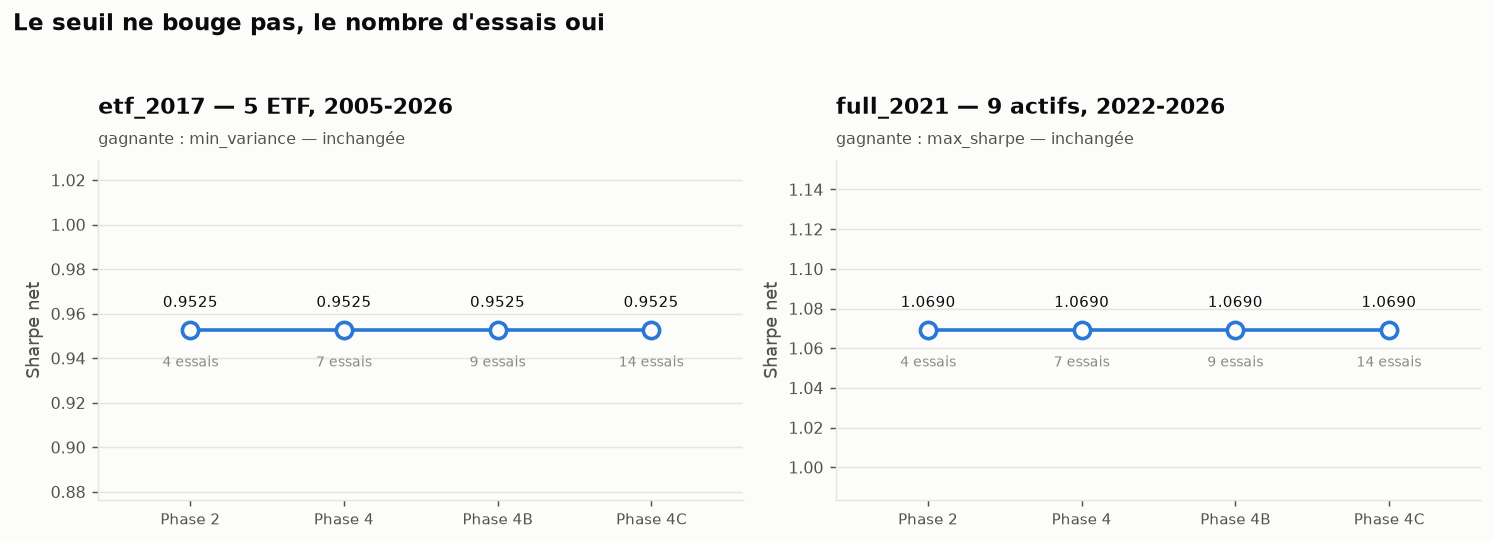

In [3]:
if not chaine.empty:
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=False)
    for ax, uni in zip(axes, UNIVERS):
        sous = chaine[chaine["univers"] == uni]
        x = np.arange(len(sous))
        ax.plot(x, sous["sharpe net"], color=BLEU, lw=2,
                marker="o", ms=9, mfc=SURFACE, mec=BLEU, mew=2, zorder=3)
        for xi, (_, r) in zip(x, sous.iterrows()):
            ax.annotate(f'{r["sharpe net"]:.4f}', (xi, r["sharpe net"]),
                        textcoords="offset points", xytext=(0, 13),
                        ha="center", fontsize=8.5, color=ENCRE)
            ax.annotate(f'{r["essais"]} essais', (xi, r["sharpe net"]),
                        textcoords="offset points", xytext=(0, -20),
                        ha="center", fontsize=8, color=ENCRE_3)
        ax.set_xticks(x)
        ax.set_xticklabels([p.split(" (")[0] for p in sous["phase"]], fontsize=8.5)
        ax.margins(x=0.20)  # évite que les étiquettes des extrémités soient rognées
        marge = max(0.06, sous["sharpe net"].max() * 0.08)
        ax.set_ylim(sous["sharpe net"].min() - marge, sous["sharpe net"].max() + marge)
        ax.grid(axis="x", visible=False)
        habiller(ax, NOMS_UNIVERS[uni],
                 f'gagnante : {sous["stratégie gagnante"].iloc[-1]} — inchangée',
                 ylabel="Sharpe net")
    fig.suptitle("Le seuil ne bouge pas, le nombre d'essais oui",
                 x=0.005, ha="left", fontsize=13, fontweight="bold", color=ENCRE)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

**Lecture.** La ligne est horizontale : quatre phases de raffinement n'ont pas
déplacé le Sharpe net d'un millième. Le compteur d'essais, lui, monte de 4 à 14
— et il ne monte jamais gratuitement. Chaque configuration essayée entre dans le
**même vivier DSR** (*deflated Sharpe ratio*) par univers : ajouter des essais à
un espace déjà fouillé déflate le Sharpe de tout ce qui s'y trouve. Une ligne
plate assortie d'un compteur qui monte est donc, en toute rigueur, une
**dégradation** de la force de preuve et non une stagnation.

## 2. Phase 4C — le signal était informatif, le trader ne l'était pas

Phase 4C teste quatre remèdes de construction de portefeuille (pénalisation du
turnover, rétrécissement de `mu`, conservation du seul *rang*, et l'appariement
`mu` + DCC-GARCH). Le graphique met le Sharpe **brut** en regard du Sharpe
**net** : l'écart entre les deux points est exactement la facture de
transaction.

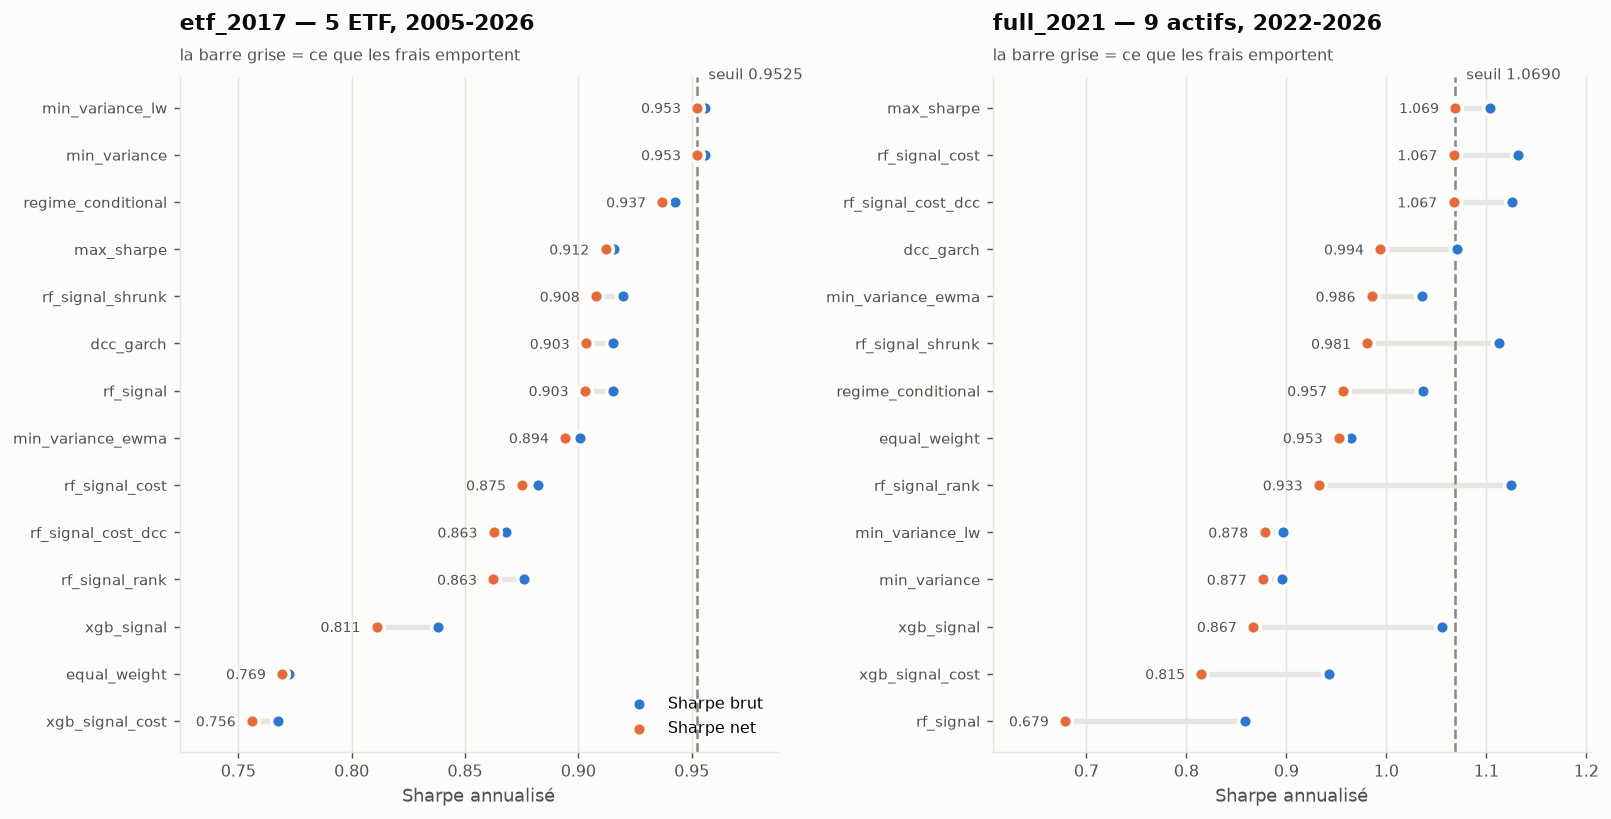

**`full_2021` — les stratégies qui battent la référence en brut :**

univers,stratégie,sharpe brut,sharpe net,facture,turnover moyen
full_2021,rf_signal_cost,1.1318,1.0673,0.0645,0.309
full_2021,rf_signal_cost_dcc,1.1259,1.0672,0.0587,0.281
full_2021,rf_signal_rank,1.1248,0.9327,0.1921,1.039
full_2021,rf_signal_shrunk,1.1126,0.9810,0.1316,0.630


In [4]:
if p4c is None:
    display(Markdown("> `phase4c_results.json` indisponible — section ignorée."))
else:
    rangs = []
    for uni in UNIVERS:
        for nom, v in p4c[uni]["per_strategy"].items():
            rangs.append({"univers": uni, "stratégie": nom,
                          "sharpe brut": v["sharpe_gross"], "sharpe net": v["sharpe_net"],
                          "facture": v["sharpe_gross"] - v["sharpe_net"],
                          "turnover moyen": v["avg_turnover"]})
    p4c_df = pd.DataFrame(rangs)

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 6.4))
    for ax, uni in zip(axes, UNIVERS):
        sous = p4c_df[p4c_df["univers"] == uni].sort_values("sharpe net")
        y = np.arange(len(sous))
        seuil = p4c[uni]["phase4_hurdle"]["sharpe_net"]

        ax.hlines(y, sous["sharpe net"], sous["sharpe brut"],
                  color=GRILLE, lw=3, zorder=1)
        ax.scatter(sous["sharpe brut"], y, s=58, color=BLEU, zorder=3,
                   edgecolor=SURFACE, linewidth=2, label="Sharpe brut")
        ax.scatter(sous["sharpe net"], y, s=58, color=ORANGE, zorder=3,
                   edgecolor=SURFACE, linewidth=2, label="Sharpe net")
        ax.axvline(seuil, color=ENCRE_3, ls="--", lw=1.4, zorder=2)
        ax.annotate(f"seuil {seuil:.4f}", (seuil, len(sous) - 0.4),
                    textcoords="offset points", xytext=(6, 0),
                    fontsize=8.5, color=ENCRE_2)
        for yi, (_, r) in zip(y, sous.iterrows()):
            ax.annotate(f'{r["sharpe net"]:.3f}', (r["sharpe net"], yi),
                        textcoords="offset points", xytext=(-9, -3),
                        ha="right", fontsize=7.8, color=ENCRE_2)
        ax.set_yticks(y); ax.set_yticklabels(sous["stratégie"], fontsize=8.5)
        # marge à gauche : les valeurs les plus basses portent une étiquette
        # déportée vers la gauche, qui sinon chevaucherait les noms de stratégie
        ax.margins(x=0.16)
        ax.grid(axis="y", visible=False)
        habiller(ax, NOMS_UNIVERS[uni],
                 "la barre grise = ce que les frais emportent",
                 xlabel="Sharpe annualisé")
        if uni == UNIVERS[0]:
            ax.legend(loc="lower right")
    fig.tight_layout()
    plt.show()

    display(Markdown("**`full_2021` — les stratégies qui battent la référence en brut :**"))
    seuil_brut = p4c["full_2021"]["per_strategy"]["max_sharpe"]["sharpe_gross"]
    gagnantes = (p4c_df[(p4c_df["univers"] == "full_2021") &
                        (p4c_df["sharpe brut"] > seuil_brut)]
                 .sort_values("sharpe brut", ascending=False))
    display(gagnantes.style.hide(axis="index").format({
        "sharpe brut": "{:.4f}", "sharpe net": "{:.4f}",
        "facture": "{:.4f}", "turnover moyen": "{:.3f}"}))

**Lecture.** Les deux univers racontent deux histoires opposées, et c'est le
point le plus important de cette section.

Sur **`etf_2017`**, `min_variance` détient le meilleur Sharpe **brut** des
quatorze stratégies. Il n'y a donc aucun problème de coût à résoudre : la
machinerie ajoutée (GARCH, régime, ML) ne produit tout simplement pas d'alpha
brut. On ne répare pas un moteur qui tourne à vide.

Sur **`full_2021`**, c'est l'inverse : quatre variantes dépassent la référence
en brut, et toutes la perdent en net. `rf_signal_cost` gagne **+0,028** de
Sharpe brut et rend **+0,030** de frais supplémentaires — un déficit net de
**0,0017**. La pénalisation de turnover a bien fonctionné (elle ramène la
facture de `rf_signal` de 0,178 à 0,065) ; elle s'arrête à deux millièmes du
but.

C'est un échec quantitatif, pas qualitatif : le diagnostic « le signal est
informatif, l'exécuter n'est pas abordable » est confirmé, et le remède est
correctement orienté.

## 3. Phase 5 — le seul verdict positif, et ce qu'il vaut

Phase 5 est la seule phase à sélectionner ses hyperparamètres **honnêtement** :
validation croisée *purged walk-forward* sur le segment d'apprentissage, gel des
réglages, puis verdict unique sur un segment de test jamais vu. C'est aussi la
seule à renvoyer `beats_hurdle_on_test: true`.

Les barres d'erreur sont les intervalles de confiance *block-bootstrap*. Elles
sont la raison pour laquelle ce verdict doit être lu avec prudence.

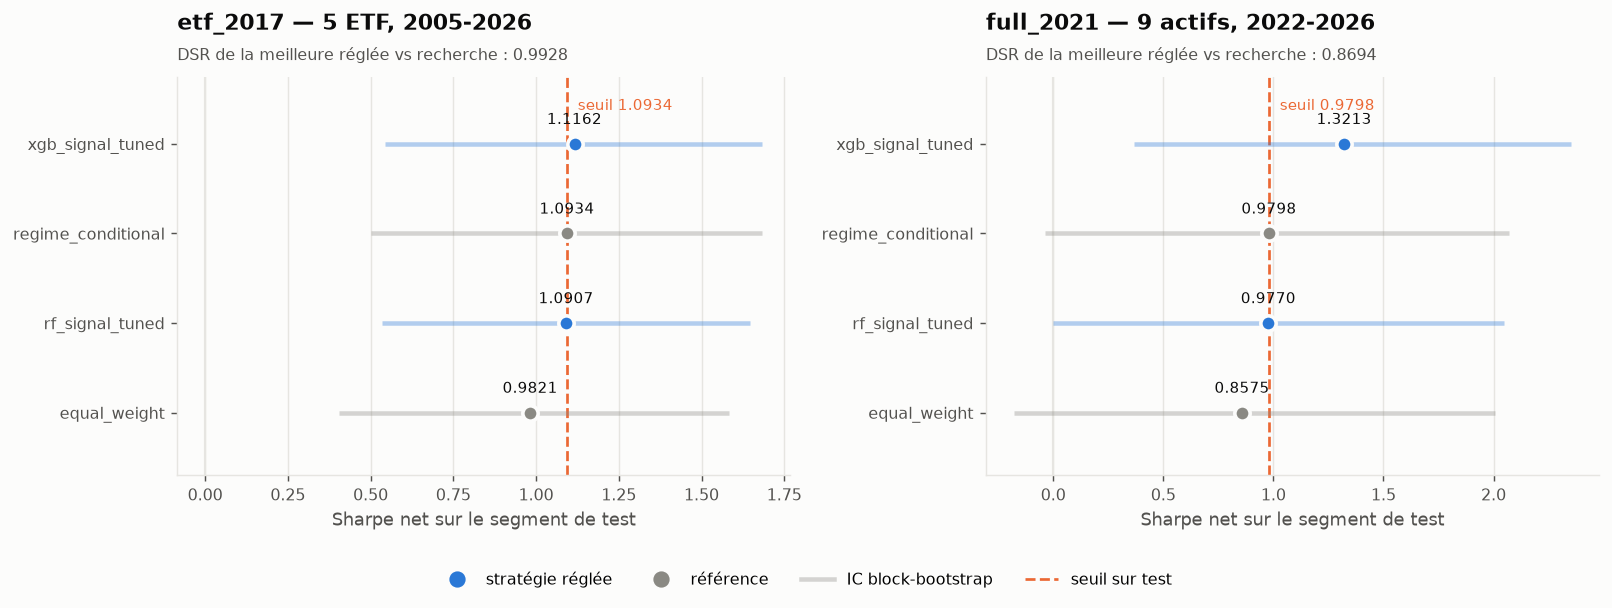

univers,stratégie,type,sharpe test,ic bas,ic haut,drawdown max
etf_2017,rf_signal_tuned,réglée,1.0907,0.5332,1.6458,-0.2660
etf_2017,xgb_signal_tuned,réglée,1.1162,0.5445,1.6843,-0.2637
etf_2017,regime_conditional,référence,1.0934,0.5017,1.6822,—
etf_2017,equal_weight,référence,0.9821,0.4056,1.5827,—
full_2021,rf_signal_tuned,réglée,0.9770,-0.0013,2.0475,-0.1144
full_2021,xgb_signal_tuned,réglée,1.3213,0.3653,2.3523,-0.1081
full_2021,regime_conditional,référence,0.9798,-0.0389,2.0712,—
full_2021,equal_weight,référence,0.8575,-0.1792,2.0070,—


In [5]:
if p5 is None:
    display(Markdown("> `phase5_results.json` indisponible — section ignorée."))
else:
    rangs = []
    for uni in UNIVERS:
        for nom, v in p5[uni]["tuned"].items():
            rangs.append({"univers": uni, "stratégie": nom, "type": "réglée",
                          "sharpe test": v["test_sharpe_net"],
                          "ic bas": v["test_sharpe_ci"][0], "ic haut": v["test_sharpe_ci"][1],
                          "drawdown max": v["test_max_drawdown"]})
        for nom, v in p5[uni]["baselines"].items():
            rangs.append({"univers": uni, "stratégie": nom, "type": "référence",
                          "sharpe test": v["test_sharpe_net"],
                          "ic bas": v["test_sharpe_ci"][0], "ic haut": v["test_sharpe_ci"][1],
                          "drawdown max": np.nan})
    p5_df = pd.DataFrame(rangs)

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
    for ax, uni in zip(axes, UNIVERS):
        sous = p5_df[p5_df["univers"] == uni].sort_values("sharpe test")
        y = np.arange(len(sous))
        couleurs = [BLEU if t == "réglée" else ENCRE_3 for t in sous["type"]]
        for yi, (_, r), c in zip(y, sous.iterrows(), couleurs):
            ax.hlines(yi, r["ic bas"], r["ic haut"], color=c, lw=2.5, alpha=0.35, zorder=2)
            ax.scatter(r["sharpe test"], yi, s=72, color=c, zorder=3,
                       edgecolor=SURFACE, linewidth=2)
            ax.annotate(f'{r["sharpe test"]:.4f}', (r["sharpe test"], yi),
                        textcoords="offset points", xytext=(0, 11),
                        ha="center", fontsize=8.2, color=ENCRE)
        seuil = p5[uni]["hurdle_on_test"]["test_sharpe_net"]
        ax.axvline(seuil, color=ORANGE, ls="--", lw=1.5, zorder=1)
        # étiquette du seuil en haut : le bas de l'axe est occupé par les CI
        ax.annotate(f'seuil {seuil:.4f}', xy=(seuil, 1), xycoords=("data", "axes fraction"),
                    textcoords="offset points", xytext=(6, -12),
                    fontsize=8.5, color=ORANGE, va="top")
        ax.axvline(0, color=GRILLE, lw=1.2, zorder=0)
        ax.set_yticks(y); ax.set_yticklabels(sous["stratégie"], fontsize=9)
        ax.set_ylim(-0.7, len(sous) - 0.25)
        ax.grid(axis="y", visible=False)
        dsr = p5[uni]["best_tuned_dsr_vs_search"]
        habiller(ax, NOMS_UNIVERS[uni],
                 f'DSR de la meilleure réglée vs recherche : {dsr:.4f}',
                 xlabel="Sharpe net sur le segment de test")
    # légende partagée SOUS les deux panneaux : aucun recouvrement possible
    fig.legend(handles=[
        Line2D([], [], marker="o", ls="", color=BLEU, ms=8, label="stratégie réglée"),
        Line2D([], [], marker="o", ls="", color=ENCRE_3, ms=8, label="référence"),
        Line2D([], [], color=ENCRE_3, lw=2.5, alpha=0.35,
               label="IC block-bootstrap"),
        Line2D([], [], color=ORANGE, ls="--", lw=1.5, label="seuil sur test"),
    ], loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.02))
    fig.tight_layout(rect=[0, 0.07, 1, 1])
    plt.show()

    display(p5_df.style.hide(axis="index").format({
        "sharpe test": "{:.4f}", "ic bas": "{:.4f}",
        "ic haut": "{:.4f}", "drawdown max": "{:.4f}"}, na_rep="—"))

**Lecture.** Le verdict est positif sur les deux univers — et il faut dire
précisément à quel point il est fragile.

D'un côté, le mécanisme est exactement celui que la phase 4C avait annoncé. Sa
note d'honnêteté disait que `turnover_penalty` et `shrinkage_weight` y étaient
*choisis et non ajustés*, et que la phase 5 serait le lieu de leur sélection
honnête. La phase 5 retient `turnover_penalty = 2.0` pour les deux variantes
XGBoost — le double de la valeur codée en dur en 4C. Le remède qui échouait de
0,0017 avec un réglage à la main réussit avec un réglage appris. C'est un
résultat de méthode.

De l'autre, **les intervalles de confiance avalent le résultat**. Sur
`etf_2017`, la marge est de +0,023 pour un intervalle large de 1,1 ; sur
`full_2021`, +0,342 pour un intervalle large de 2,0. Tous les intervalles se
recouvrent. Et le DSR sépare les deux univers dans le sens contre-intuitif :
0,9928 sur `etf_2017` mais **0,8694 sur `full_2021`** — c'est-à-dire que la
marge la plus *large* est celle qui survit le moins bien à la correction pour
recherche multiple, parce que son segment de test ne dure que 21 mois.

## 4. Reality Check — ce qui reste après correction pour recherche multiple

L'étape `reality_check` rejoue les **240 candidats atteignables** par univers sur
les dates de test gelées, puis applique le *Reality Check* de White (2000) et le
*SPA* de Hansen (2005). L'hypothèse nulle : *aucun candidat de l'ensemble
fouillé ne bat la référence*.

La distinction `primary` / `exploratory` est décisive : la référence
**primaire** est `regime_conditional` (le système effectivement défendu), tandis
que `equal_weight` n'est qu'un repère exploratoire.

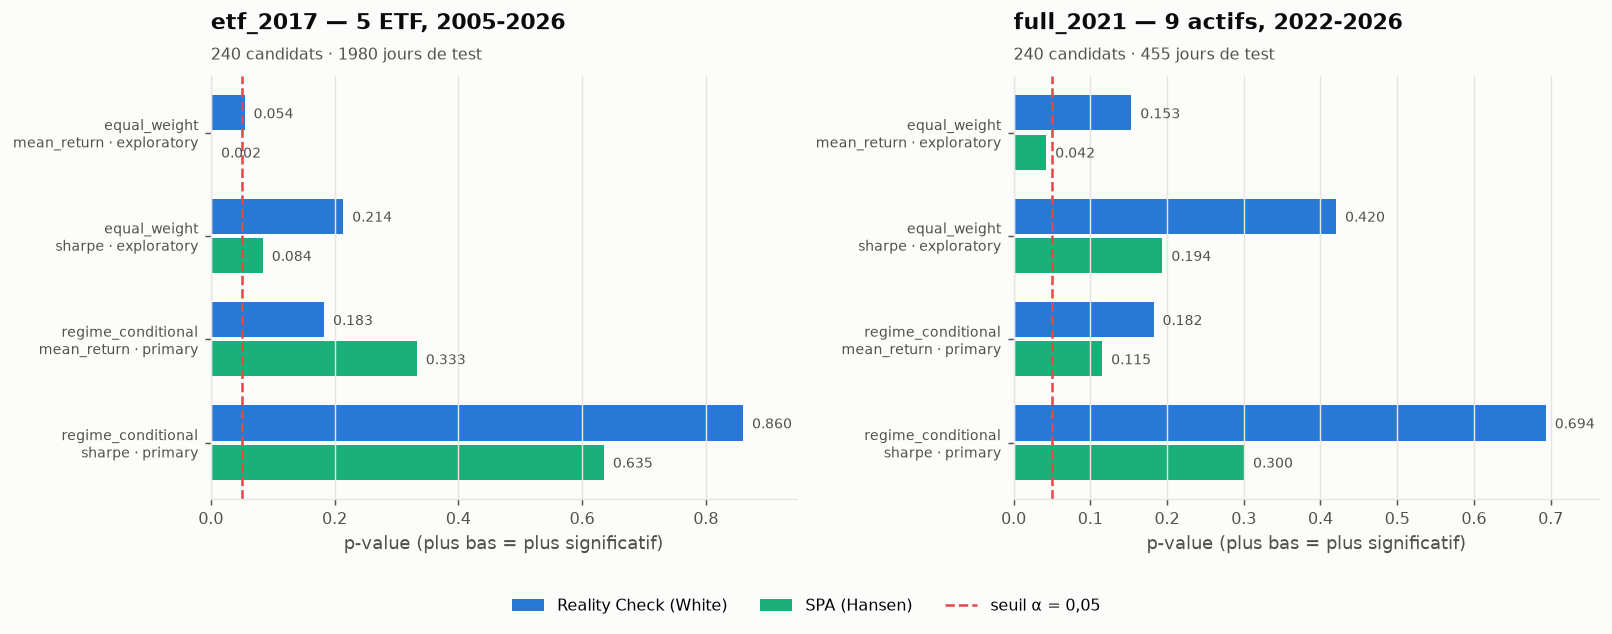

univers,référence,statistique,statut,RC p,SPA p,candidats battant la réf.,n candidats
etf_2017,equal_weight,mean_return,exploratory,0.0545,0.0020,186,240
etf_2017,equal_weight,sharpe,exploratory,0.2139,0.0840,222,240
etf_2017,regime_conditional,mean_return,primary,0.1829,0.3328,130,240
etf_2017,regime_conditional,sharpe,primary,0.8601,0.6352,95,240
full_2021,equal_weight,mean_return,exploratory,0.1534,0.0425,169,240
full_2021,equal_weight,sharpe,exploratory,0.4203,0.1939,124,240
full_2021,regime_conditional,mean_return,primary,0.1824,0.1154,147,240
full_2021,regime_conditional,sharpe,primary,0.6937,0.3003,100,240


In [6]:
if rc is None:
    display(Markdown("> `reality_check_results.json` indisponible — section ignorée."))
else:
    rangs = []
    for uni, v in rc["universes"].items():
        for nom, t in v["tests"].items():
            ref, stat = nom.split("__")
            rangs.append({"univers": uni, "référence": ref, "statistique": stat,
                          "statut": t["status"], "RC p": t["reality_check_p_value"],
                          "SPA p": t["spa_p_value"],
                          "candidats battant la réf.": t["n_candidates_beating_benchmark"],
                          "n candidats": t["n_candidates"]})
    rc_df = pd.DataFrame(rangs)

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
    for ax, uni in zip(axes, UNIVERS):
        sous = rc_df[rc_df["univers"] == uni].iloc[::-1]
        y = np.arange(len(sous))
        pas, larg = 0.19, 0.34        # 2·pas > larg ⇒ filet de surface entre les deux barres
        ax.barh(y + pas, sous["RC p"], height=larg, color=BLEU, label="Reality Check (White)")
        ax.barh(y - pas, sous["SPA p"], height=larg, color=AQUA, label="SPA (Hansen)")
        for yi, (_, r) in zip(y, sous.iterrows()):
            ax.annotate(f'{r["RC p"]:.3f}', (r["RC p"], yi + pas),
                        textcoords="offset points", xytext=(5, -3),
                        fontsize=7.8, color=ENCRE_2)
            ax.annotate(f'{r["SPA p"]:.3f}', (r["SPA p"], yi - pas),
                        textcoords="offset points", xytext=(5, -3),
                        fontsize=7.8, color=ENCRE_2)
        # le seuil est nommé dans la légende partagée : pas d'étiquette dans le cadre
        ax.axvline(0.05, color=ROUGE, ls="--", lw=1.4)
        ax.margins(x=0.10)
        ax.set_yticks(y)
        ax.set_yticklabels([f'{r["référence"]}\n{r["statistique"]} · {r["statut"]}'
                            for _, r in sous.iterrows()], fontsize=8)
        ax.grid(axis="y", visible=False)
        habiller(ax, NOMS_UNIVERS[uni],
                 f'{sous["n candidats"].iloc[0]} candidats · '
                 f'{rc["universes"][uni]["n_test_days"]} jours de test',
                 xlabel="p-value (plus bas = plus significatif)")
    # légende partagée sous les panneaux : les barres occupent tout le cadre
    handles, labels = axes[0].get_legend_handles_labels()
    handles.append(Line2D([], [], color=ROUGE, ls="--", lw=1.4))
    labels.append("seuil α = 0,05")
    fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))
    fig.tight_layout(rect=[0, 0.07, 1, 1])
    plt.show()

    display(rc_df.style.hide(axis="index").format({"RC p": "{:.4f}", "SPA p": "{:.4f}"}))

**Lecture.** Contre la référence **primaire** (`regime_conditional`), rien ne
passe : les p-values du Reality Check vont de 0,18 à 0,86 sur les deux univers
et les deux statistiques. Après correction pour l'ampleur de la recherche,
**aucun des 240 candidats ne bat le système défendu**.

Les seules p-values basses sont exploratoires, contre `equal_weight`, et elles
se contredisent : sur `etf_2017` en rendement moyen, RC donne 0,054 (au-dessus
du seuil) tandis que SPA donne 0,002 (bien en dessous). L'écart entre les deux
n'est pas une anomalie — le SPA écarte les candidats trop médiocres pour peser
sur la distribution nulle, et devient donc plus puissant quand beaucoup de
candidats sont mauvais. Ici, 186 des 240 candidats battent `equal_weight` : le
repère 1/N est simplement faible sur cet univers, ce que la section 6 explique.

Mettre ce résultat en regard de la section 3 est instructif : la phase 5
annonce `beats_hurdle_on_test: true`, le Reality Check répond « pas après
correction ». Les deux sont exacts — ils ne posent pas la même question. La
phase 5 teste **une** stratégie gelée ; le Reality Check teste **l'espace de
recherche entier** qui a produit cette stratégie. C'est le second qui décrit
honnêtement la force de preuve.

## 5. `fit_reports` — ce que les replis silencieux cachent dans les moyennes

Un estimateur qui ne converge pas ne s'arrête pas : il **se replie** sur une
solution de secours. `fit_reports` audite les quatre stratégies dotées d'un
chemin de repli et impose une règle de lecture :

> *La performance pleine période est l'**hybride** du modèle demandé et de son
> repli — jamais le modèle demandé seul.*

Le graphique sépare les trois régimes : les jours où le modèle demandé a tourné,
les jours de repli, et l'hybride effectivement publié.

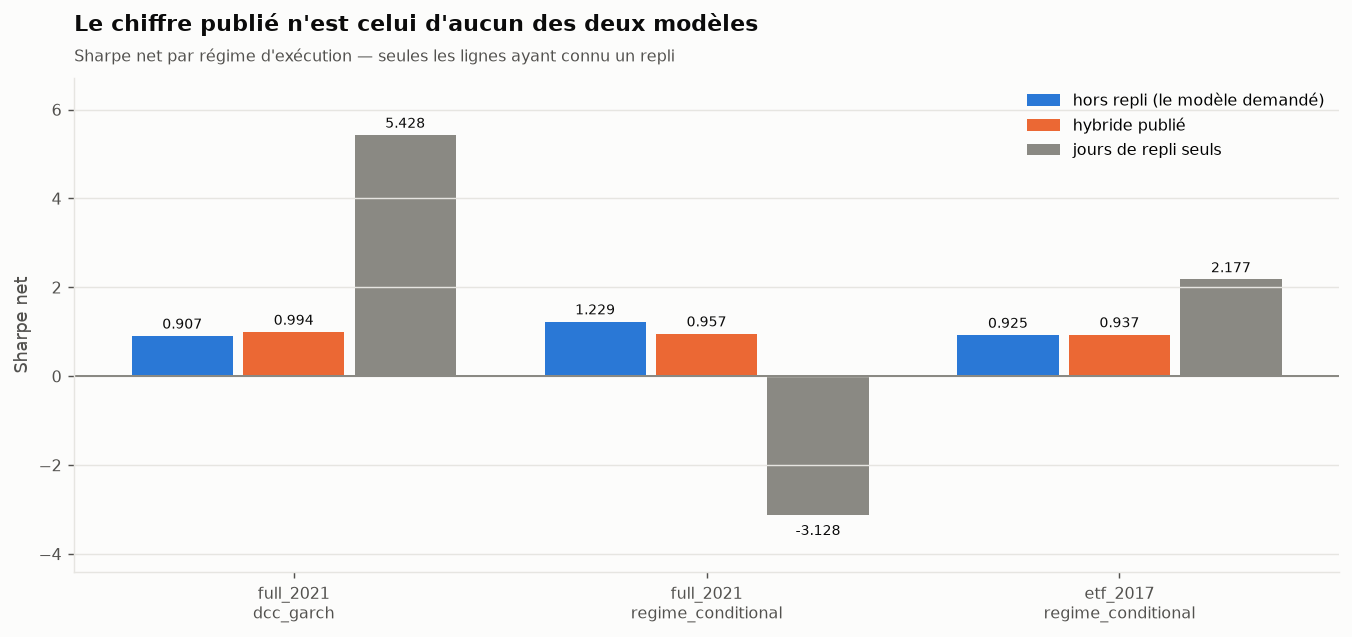

univers,stratégie,repli (rééquilibrages),jours de repli,jours OOS,hors repli,jours de repli (sharpe),hybride publié
full_2021,dcc_garch,0.0208,21,1040,0.9071,5.4280,0.9939
full_2021,regime_conditional,0.0625,65,1040,1.2288,-3.1282,0.9571
full_2021,rf_signal,0.0000,0,1040,0.6788,—,0.6788
full_2021,xgb_signal,0.0000,0,1040,0.8668,—,0.8668
etf_2017,dcc_garch,0.0000,0,5387,0.9034,—,0.9034
etf_2017,regime_conditional,0.0121,63,5387,0.9255,2.1768,0.9371
etf_2017,rf_signal,0.0000,0,5387,0.9029,—,0.9029
etf_2017,xgb_signal,0.0000,0,5387,0.8111,—,0.8111


In [7]:
if fit is None:
    display(Markdown("> `fit_report_summary.json` indisponible — section ignorée."))
else:
    rangs = []
    for r in fit["results"]:
        perf = r["performance"]
        rangs.append({
            "univers": r["universe"], "stratégie": r["strategy_requested"],
            "repli (rééquilibrages)": r["fallback_rate_rebalances"],
            "jours de repli": r["fallback_days"], "jours OOS": r["oos_days"],
            "hors repli": perf["excluding_fallback"]["net_sharpe"],
            "jours de repli (sharpe)": perf["fallback_periods"]["net_sharpe"],
            "hybride publié": perf["full_period_hybrid"]["net_sharpe"],
        })
    fit_df = pd.DataFrame(rangs)
    avec_repli = fit_df[fit_df["jours de repli"] > 0].copy()

    if not avec_repli.empty:
        etiquettes = [f'{r["univers"]}\n{r["stratégie"]}' for _, r in avec_repli.iterrows()]
        x = np.arange(len(avec_repli))
        pas, larg = 0.27, 0.245           # pas > largeur ⇒ filet de surface entre barres
        fig, ax = plt.subplots(figsize=(10.5, 5.0))
        ax.bar(x - pas, avec_repli["hors repli"], width=larg, color=BLEU,
               label="hors repli (le modèle demandé)")
        ax.bar(x, avec_repli["hybride publié"], width=larg, color=ORANGE,
               label="hybride publié")
        ax.bar(x + pas, avec_repli["jours de repli (sharpe)"], width=larg, color=ENCRE_3,
               label="jours de repli seuls")
        for xi, (_, r) in zip(x, avec_repli.iterrows()):
            for dx, v in [(-pas, r["hors repli"]), (0, r["hybride publié"]),
                          (pas, r["jours de repli (sharpe)"])]:
                ax.annotate(f"{v:.3f}", (xi + dx, v),
                            textcoords="offset points",
                            xytext=(0, 4 if v >= 0 else -11),
                            ha="center", fontsize=8, color=ENCRE)
        ax.axhline(0, color=ENCRE_3, lw=1.1)
        ax.set_xticks(x); ax.set_xticklabels(etiquettes, fontsize=9)
        ax.margins(y=0.15)  # place pour les étiquettes au-dessus/au-dessous des barres
        ax.grid(axis="x", visible=False)
        habiller(ax, "Le chiffre publié n'est celui d'aucun des deux modèles",
                 "Sharpe net par régime d'exécution — seules les lignes ayant connu un repli",
                 ylabel="Sharpe net")
        ax.legend(loc="upper right")
        fig.tight_layout(); plt.show()

    display(fit_df.style.hide(axis="index").format({
        "repli (rééquilibrages)": "{:.4f}", "hors repli": "{:.4f}",
        "jours de repli (sharpe)": "{:.4f}", "hybride publié": "{:.4f}"}, na_rep="—"))

**Lecture.** Les taux de repli sont faibles — au plus 6,2 % des rééquilibrages —
et pourtant ils déplacent les chiffres publiés de façon décisive, **dans les
deux sens**.

Sur `full_2021`, `regime_conditional` réalise un Sharpe de **1,229** les jours où
le HMM a effectivement tourné. Les 65 jours de repli, eux, rendent **−3,128**.
L'hybride publié tombe à 0,957 : 6 % des jours effacent un quart du Sharpe. La
sous-stratégie défensive, appelée sur une postérieure neutre 50/50, est ce qui
coûte le plus cher.

Sur la même période, `dcc_garch` va dans l'autre sens. Son repli — une seule
fenêtre, 21 jours, causée par la non-convergence du GARCH(1,1) sur `IAM.CS` —
rapporte un Sharpe de **+5,428**, et tire l'hybride publié de 0,907 à **0,994**.
Autrement dit : le 0,994 que l'on serait tenté d'attribuer au DCC-GARCH est
**flatté par 21 jours où le DCC-GARCH n'a pas tourné**. Le chiffre du modèle
seul est 0,907.

C'est précisément ce que la règle de l'hybride existe pour rendre visible. Un
repli rare n'est pas un repli sans conséquence, et sa contribution n'a aucune
raison d'être neutre.

## 6. Le balayage du plafond de poids — la contrainte fait le travail de l'estimateur

Les sections 1 et 2 laissent une énigme : pourquoi, sur `etf_2017`, aucune
stratégie ne se distingue, pas même en brut ? L'étape `etf_cap_sweep` répond en
faisant varier `backtest.max_weight`.

L'arithmétique donne déjà l'intuition. Avec 5 actifs plafonnés à 25 %, le total
maximal atteignable est 1,25 pour une somme requise de 1,00 : **au moins quatre
positions doivent être à leur plafond à chaque date**. L'optimiseur n'a
quasiment aucune liberté — et le drapeau `optimizer_free` du pipeline le
confirme.

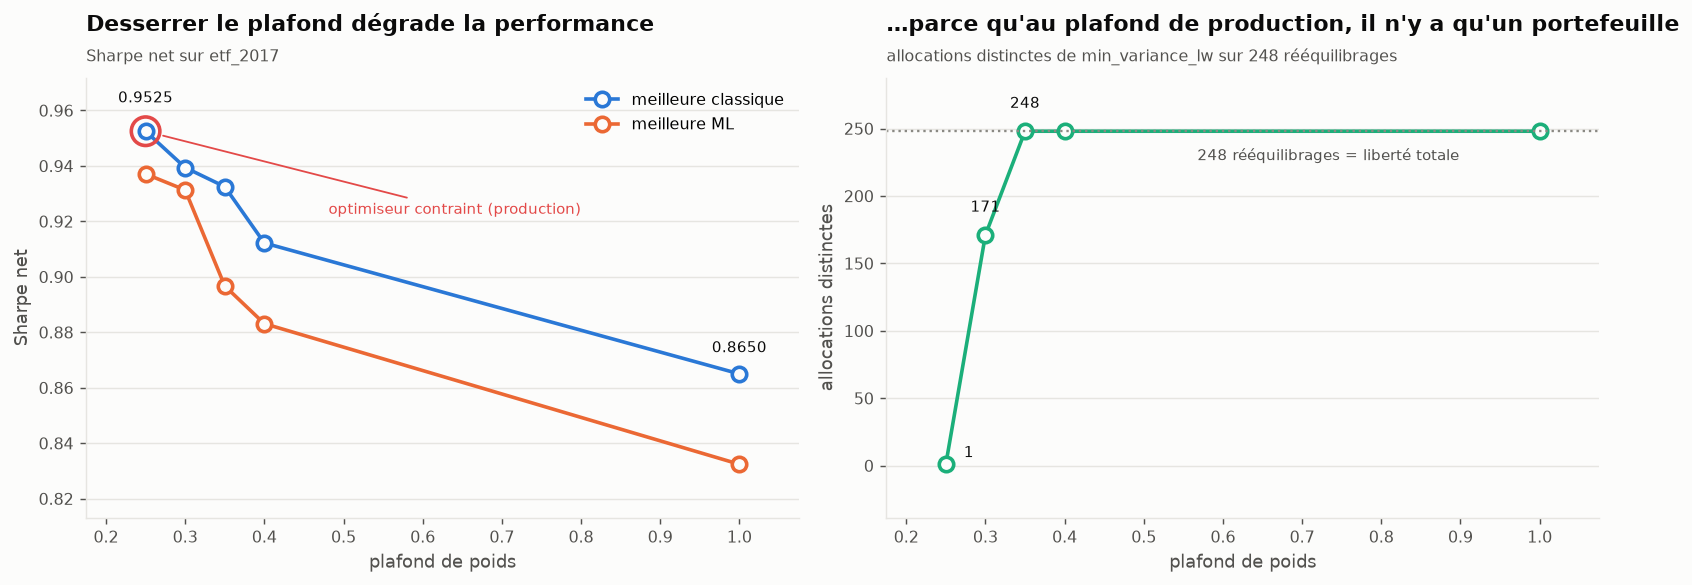

plafond,meilleure classique,sharpe classique,sharpe ML,apport ML (%),optimiseur libre,allocations distinctes (min_var_lw),n rééquilibrages
0.250000,min_variance_lw,0.9525,0.9371,-1.62,False,1,248
0.300000,min_variance_lw,0.9394,0.9313,-0.86,True,171,248
0.350000,min_variance_lw,0.9325,0.8967,-3.84,True,248,248
0.400000,max_sharpe,0.9122,0.8831,-3.19,True,248,248
1.000000,max_sharpe,0.8650,0.8324,-3.77,True,248,248


In [8]:
if cap is None:
    display(Markdown("> `etf_cap_verdict.json` indisponible — section ignorée."))
else:
    rangs = []
    for c in cap["caps"]:
        k = str(c) if str(c) in cap["results"] else f"{c:.2f}"
        res, verdict = cap["results"][k], cap["verdicts"][k]
        rangs.append({
            "plafond": c,
            "meilleure classique": verdict["best_classical"],
            "sharpe classique": verdict["classical_sharpe"],
            "sharpe ML": verdict["ml_sharpe"],
            "apport ML (%)": verdict["lift_pct"],
            "optimiseur libre": verdict["optimizer_free"],
            "allocations distinctes (min_var_lw)": res["min_variance_lw"]["distinct_allocations"],
            "n rééquilibrages": res["min_variance_lw"]["n_rebalances"],
        })
    cap_df = pd.DataFrame(rangs)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))

    ax1.plot(cap_df["plafond"], cap_df["sharpe classique"], color=BLEU, lw=2,
             marker="o", ms=8, mfc=SURFACE, mec=BLEU, mew=2, label="meilleure classique")
    ax1.plot(cap_df["plafond"], cap_df["sharpe ML"], color=ORANGE, lw=2,
             marker="o", ms=8, mfc=SURFACE, mec=ORANGE, mew=2, label="meilleure ML")
    # étiquettes SÉLECTIVES : les deux extrémités suffisent à porter la pente
    for idx, dy in [(0, 16), (len(cap_df) - 1, 12)]:
        r = cap_df.iloc[idx]
        ax1.annotate(f'{r["sharpe classique"]:.4f}', (r["plafond"], r["sharpe classique"]),
                     textcoords="offset points", xytext=(0, dy), ha="center",
                     fontsize=8.5, color=ENCRE)
    lie = cap_df[~cap_df["optimiseur libre"]]
    if not lie.empty:
        ax1.scatter(lie["plafond"], lie["sharpe classique"], s=250, facecolors="none",
                    edgecolors=ROUGE, linewidths=2, zorder=5)
        # texte calé en fraction d'axes (zone vide entre la légende et la courbe
        # classique), relié au point entouré — placement stable quel que soit l'échelle
        ax1.annotate("optimiseur contraint (production)",
                     xy=(lie["plafond"].iloc[0], lie["sharpe classique"].iloc[0]),
                     xytext=(0.34, 0.70), textcoords="axes fraction",
                     fontsize=8.5, color=ROUGE, ha="left", va="center",
                     arrowprops=dict(arrowstyle="-", color=ROUGE, lw=1,
                                     shrinkA=2, shrinkB=10))
    ax1.margins(x=0.10, y=0.16)
    ax1.grid(axis="x", visible=False)
    habiller(ax1, "Desserrer le plafond dégrade la performance",
             "Sharpe net sur etf_2017", xlabel="plafond de poids", ylabel="Sharpe net")
    ax1.legend(loc="upper right")

    ax2.plot(cap_df["plafond"], cap_df["allocations distinctes (min_var_lw)"],
             color=AQUA, lw=2, marker="o", ms=8, mfc=SURFACE, mec=AQUA, mew=2)
    # étiquettes SÉLECTIVES : seul le décollage 1 → 171 → 248 porte l'argument
    for idx, (dx, dy, ha) in [(0, (10, 4, "left")), (1, (0, 13, "center")),
                              (2, (0, 13, "center"))][:len(cap_df)]:
        r = cap_df.iloc[idx]
        ax2.annotate(f'{int(r["allocations distinctes (min_var_lw)"])}',
                     (r["plafond"], r["allocations distinctes (min_var_lw)"]),
                     textcoords="offset points", xytext=(dx, dy), ha=ha,
                     fontsize=8.5, color=ENCRE)
    n_reb = int(cap_df["n rééquilibrages"].iloc[0])
    ax2.axhline(n_reb, color=ENCRE_3, ls=":", lw=1.3)
    # annotation calée à MI-PARCOURS : les points extrêmes portent déjà des étiquettes
    ax2.annotate(f'{n_reb} rééquilibrages = liberté totale',
                 xy=(0.62, n_reb), xycoords=("axes fraction", "data"),
                 textcoords="offset points", xytext=(0, -16), ha="center",
                 fontsize=8.5, color=ENCRE_2)
    ax2.margins(x=0.10, y=0.16)
    ax2.grid(axis="x", visible=False)
    habiller(ax2, "…parce qu'au plafond de production, il n'y a qu'un portefeuille",
             "allocations distinctes de min_variance_lw sur 248 rééquilibrages",
             xlabel="plafond de poids", ylabel="allocations distinctes")
    fig.tight_layout(); plt.show()

    display(cap_df.style.hide(axis="index").format({
        "sharpe classique": "{:.4f}", "sharpe ML": "{:.4f}", "apport ML (%)": "{:.2f}"}))

**Lecture.** Le panneau de droite est sans appel : au plafond de production de
25 %, `min_variance_lw` ne produit **qu'une seule allocation distincte sur 248
rééquilibrages**. Le portefeuille est entièrement déterminé par la contrainte ;
l'estimateur de covariance n'a aucun effet. Le pipeline l'étiquette lui-même
`optimizer_free: false`. L'énigme de la section 2 est résolue : aucune stratégie
ne se distingue sur `etf_2017` parce qu'aucune n'est réellement autorisée à
différer.

Mais la conclusion attendue — « desserrons le plafond pour libérer l'alpha » —
est **fausse**, et c'est le résultat le plus intéressant du tableau de bord.
Relâcher la contrainte dégrade la performance de façon monotone : 0,9525 à 25 %,
puis 0,9394, 0,9325, 0,9113, et 0,8464 sans plafond. La contrainte n'étouffe pas
l'alpha : elle **fournit la régularisation**. C'est le résultat de Jagannathan &
Ma (2003), que le journal de l'étape cite explicitement — une contrainte de poids
agit comme un rétrécissement de la matrice de covariance et améliore le
hors-échantillon.

Deuxième enseignement, plus sobre : l'apport ML est **négatif à chaque plafond**
(−1,6 %, −0,9 %, −3,8 %, −3,2 %, −3,8 %). Il n'existe aucun réglage du plafond
qui rende les stratégies ML gagnantes sur cet univers.

## 7. Ce que tout cela pourrait vouloir dire

**Les deux univers posent deux problèmes distincts, et les confondre est l'erreur
à éviter.**

Sur `etf_2017`, le problème est **structurel**. Cinq actifs plafonnés à 25 %
laissent un espace admissible trop étroit pour que quoi que ce soit se distingue ;
la contrainte pilote le portefeuille, et elle le pilote *bien*. Aucun travail sur
l'estimateur — covariance, régime, ML — ne peut être évalué sur cet univers, parce
que l'univers ne laisse pas l'estimateur s'exprimer. Ce n'est pas un résultat
négatif sur les modèles : c'est un résultat négatif sur le **pouvoir
discriminant du dispositif de test**. Conclusion pratique : `etf_2017` ne devrait
plus servir à départager des estimateurs. Il reste utile comme démonstration que
la contrainte de poids est, à elle seule, une politique défendable.

Sur `full_2021`, le problème est **économique et honnêtement cerné**. Le signal
ML porte de l'information — quatre variantes battent la référence en brut — mais
son turnover de 95 % la restitue en frais. Phase 4C rate de 0,0017 avec un
réglage à la main ; phase 5, en sélectionnant honnêtement `turnover_penalty = 2,0`,
franchit le seuil. C'est un vrai progrès de méthode. Mais l'univers ne dure que
quatre ans, le segment de test 21 mois, et le DSR y tombe à 0,8694 : la marge
existe, la puissance statistique pour l'établir, non. Le Reality Check le
confirme sans ambiguïté — contre la référence primaire, aucun des 240 candidats
ne passe.

**Ce que la reconstruction a réellement changé.** Le commit `0bb87e8` a remplacé
les postérieures **lissées** par des postérieures **filtrées** (causales) dans
`attach_regime_feature`. Les postérieures lissées conditionnent sur tout
l'échantillon : toute stratégie dépendante du régime lisait donc partiellement
son propre futur. En retirant ce biais, `rf_signal` passe d'un Sharpe brut de
1,240 à 0,859 sur `full_2021`, et son turnover triple. La leçon n'est pas que le
modèle s'est dégradé — c'est que **l'avantage mesuré auparavant était en partie
un artefact de fuite d'information**. Les références classiques, elles, n'ont pas
bougé d'un millième, parce qu'elles ne touchent pas à la caractéristique de
régime. C'est pour cette raison qu'elles gagnent aujourd'hui.

**Trois conséquences pour la suite.**

1. **Ne pas lire un Sharpe publié sans son taux de repli.** Le 0,994 de
   `dcc_garch` est flatté par 21 jours sans DCC-GARCH ; le vrai chiffre est
   0,907. Inversement, `regime_conditional` vaut 1,229 quand il tourne et 0,957
   une fois l'hybride pris en compte. La colonne « hors repli » devrait
   accompagner tout chiffre cité en soutenance.
2. **Le vivier DSR est une ressource qui s'épuise.** De 4 à 14 essais en phase
   4C, 51 en phase 5, 240 au Reality Check : chaque configuration essayée
   déflate tout ce qui partage le vivier. Toute exploration supplémentaire doit
   être budgétée comme telle, et non lancée par curiosité.
3. **La sous-stratégie défensive du régime mérite un examen.** Un Sharpe de
   −3,128 sur les jours de postérieure neutre n'est pas un comportement
   acceptable pour un chemin de secours. Se replier sur `min_variance_lw` lors
   d'un démarrage à froid serait vraisemblablement préférable à la
   sous-stratégie défensive actuelle — hypothèse testable sans relancer la
   chaîne complète.

> **Ce que ce notebook ne dit pas.** Il ne contient aucun test statistique
> nouveau : les p-values, intervalles et DSR proviennent tous des artefacts. Il
> ne se prononce pas non plus sur `global_2004`, dont l'étape d'interprétation
> a été régénérée pour une raison indépendante de cette reconstruction.